<a href="https://www.kaggle.com/code/lukaspanos/house-price-prediction-xg-boost?scriptVersionId=344953464" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import pylab 
import scipy.stats as stats 
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import Ridge, Lasso
import kagglehub

In [2]:
train = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/train.csv')
test = pd.read_csv('/kaggle/input/competitions/house-prices-advanced-regression-techniques/test.csv')

In [3]:
print("Train shape:", train.shape)
print("Test shape:", test.shape)
print("\n")
print(train.dtypes.value_counts())

Train shape: (1460, 81)
Test shape: (1459, 80)


object     43
int64      35
float64     3
Name: count, dtype: int64


In [4]:
# Missing values
missing = train.isnull().sum().sort_values(ascending=False)
missing = missing[missing > 0]
missing_pct = (missing / len(train) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df)

              Missing Count  Missing %
PoolQC                 1453      99.52
MiscFeature            1406      96.30
Alley                  1369      93.77
Fence                  1179      80.75
MasVnrType              872      59.73
FireplaceQu             690      47.26
LotFrontage             259      17.74
GarageQual               81       5.55
GarageFinish             81       5.55
GarageType               81       5.55
GarageYrBlt              81       5.55
GarageCond               81       5.55
BsmtFinType2             38       2.60
BsmtExposure             38       2.60
BsmtCond                 37       2.53
BsmtQual                 37       2.53
BsmtFinType1             37       2.53
MasVnrArea                8       0.55
Electrical                1       0.07


In [5]:
# Category 1 — fill with None (categorical) or 0 (numerical)
none_cols = ['PoolQC', 'MiscFeature', 'Alley', 'Fence', 'FireplaceQu',
             'GarageType', 'GarageFinish', 'GarageQual', 'GarageCond',
             'BsmtQual', 'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2',
             'MasVnrType']

zero_cols = ['GarageYrBlt', 'MasVnrArea']

for col in none_cols:
    train[col] = train[col].fillna('None')
    
for col in zero_cols:
    train[col] = train[col].fillna(0)

# Category 2 — smart imputation
train['LotFrontage'] = train.groupby('Neighborhood')['LotFrontage'].transform(
    lambda x: x.fillna(x.median())
)
train['Electrical'] = train['Electrical'].fillna(train['Electrical'].mode()[0])

# Verify
print(train.isnull().sum().sum())  # should be 0

0


In [6]:
pd.set_option('display.max_columns', None)
train.head(20)

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,LotConfig,LandSlope,Neighborhood,Condition1,Condition2,BldgType,HouseStyle,OverallQual,OverallCond,YearBuilt,YearRemodAdd,RoofStyle,RoofMatl,Exterior1st,Exterior2nd,MasVnrType,MasVnrArea,ExterQual,ExterCond,Foundation,BsmtQual,BsmtCond,BsmtExposure,BsmtFinType1,BsmtFinSF1,BsmtFinType2,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,Heating,HeatingQC,CentralAir,Electrical,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,KitchenQual,TotRmsAbvGrd,Functional,Fireplaces,FireplaceQu,GarageType,GarageYrBlt,GarageFinish,GarageCars,GarageArea,GarageQual,GarageCond,PavedDrive,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2003,2003,Gable,CompShg,VinylSd,VinylSd,BrkFace,196.0,Gd,TA,PConc,Gd,TA,No,GLQ,706,Unf,0,150,856,GasA,Ex,Y,SBrkr,856,854,0,1710,1,0,2,1,3,1,Gd,8,Typ,0,None,Attchd,2003.0,RFn,2,548,TA,TA,Y,0,61,0,0,0,0,None,None,None,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,None,Reg,Lvl,AllPub,FR2,Gtl,Veenker,Feedr,Norm,1Fam,1Story,6,8,1976,1976,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,CBlock,Gd,TA,Gd,ALQ,978,Unf,0,284,1262,GasA,Ex,Y,SBrkr,1262,0,0,1262,0,1,2,0,3,1,TA,6,Typ,1,TA,Attchd,1976.0,RFn,2,460,TA,TA,Y,298,0,0,0,0,0,None,None,None,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,None,IR1,Lvl,AllPub,Inside,Gtl,CollgCr,Norm,Norm,1Fam,2Story,7,5,2001,2002,Gable,CompShg,VinylSd,VinylSd,BrkFace,162.0,Gd,TA,PConc,Gd,TA,Mn,GLQ,486,Unf,0,434,920,GasA,Ex,Y,SBrkr,920,866,0,1786,1,0,2,1,3,1,Gd,6,Typ,1,TA,Attchd,2001.0,RFn,2,608,TA,TA,Y,0,42,0,0,0,0,None,None,None,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,None,IR1,Lvl,AllPub,Corner,Gtl,Crawfor,Norm,Norm,1Fam,2Story,7,5,1915,1970,Gable,CompShg,Wd Sdng,Wd Shng,None,0.0,TA,TA,BrkTil,TA,Gd,No,ALQ,216,Unf,0,540,756,GasA,Gd,Y,SBrkr,961,756,0,1717,1,0,1,0,3,1,Gd,7,Typ,1,Gd,Detchd,1998.0,Unf,3,642,TA,TA,Y,0,35,272,0,0,0,None,None,None,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,None,IR1,Lvl,AllPub,FR2,Gtl,NoRidge,Norm,Norm,1Fam,2Story,8,5,2000,2000,Gable,CompShg,VinylSd,VinylSd,BrkFace,350.0,Gd,TA,PConc,Gd,TA,Av,GLQ,655,Unf,0,490,1145,GasA,Ex,Y,SBrkr,1145,1053,0,2198,1,0,2,1,4,1,Gd,9,Typ,1,TA,Attchd,2000.0,RFn,3,836,TA,TA,Y,192,84,0,0,0,0,None,None,None,0,12,2008,WD,Normal,250000
5,6,50,RL,85.0,14115,Pave,None,IR1,Lvl,AllPub,Inside,Gtl,Mitchel,Norm,Norm,1Fam,1.5Fin,5,5,1993,1995,Gable,CompShg,VinylSd,VinylSd,None,0.0,TA,TA,Wood,Gd,TA,No,GLQ,732,Unf,0,64,796,GasA,Ex,Y,SBrkr,796,566,0,1362,1,0,1,1,1,1,TA,5,Typ,0,None,Attchd,1993.0,Unf,2,480,TA,TA,Y,40,30,0,320,0,0,None,MnPrv,Shed,700,10,2009,WD,Normal,143000
6,7,20,RL,75.0,10084,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,Somerst,Norm,Norm,1Fam,1Story,8,5,2004,2005,Gable,CompShg,VinylSd,VinylSd,Stone,186.0,Gd,TA,PConc,Ex,TA,Av,GLQ,1369,Unf,0,317,1686,GasA,Ex,Y,SBrkr,1694,0,0,1694,1,0,2,0,3,1,Gd,7,Typ,1,Gd,Attchd,2004.0,RFn,2,636,TA,TA,Y,255,57,0,0,0,0,None,None,None,0,8,2007,WD,Normal,307000
7,8,60,RL,80.0,10382,Pave,None,IR1,Lvl,AllPub,Corner,Gtl,NWAmes,PosN,Norm,1Fam,2Story,7,6,1973,1973,Gable,CompShg,HdBoard,HdBoard,Stone,240.0,TA,TA,CBlock,Gd,TA,Mn,ALQ,859,BLQ,32,216,1107,GasA,Ex,Y,SBrkr,1107,983,0,2090,1,0,2,1,3,1,TA,7,Typ,2,TA,Attchd,1973.0,RFn,2,484,TA,TA,Y,235,204,228,0,0,0,None,None,Shed,350,11,2009,WD,Normal,200000
8,9,50,RM,51.0,6120,Pave,None,Reg,Lvl,AllPub,Inside,Gtl,OldTown,Artery,Norm,1Fam,1.5Fin,7,5,1931,1950,Gable,CompShg,BrkFace,Wd Shng,None,0.0,TA,TA,BrkTil,TA,TA,No,Unf,0,Unf,0,952,952,GasA,Gd,Y,FuseF,1022,752,0,1774,0,0,2,0,2,2,TA,8,Min1,2,TA,Detchd,1931.0,Unf,2,468,Fa,TA,Y,90,0,205,0,0,0,None,None,None,0,4,2008,WD,Abnorml,129900
9,10,190,RL,50.0,7420,Pave,None,Reg,Lvl,AllPub,Corner,Gtl,BrkSide,Artery,Artery,2fmCon,1.5Unf,5,6,1939,1950,Gable,CompShg,MetalSd,MetalSd,None,0.0,TA,TA,BrkT

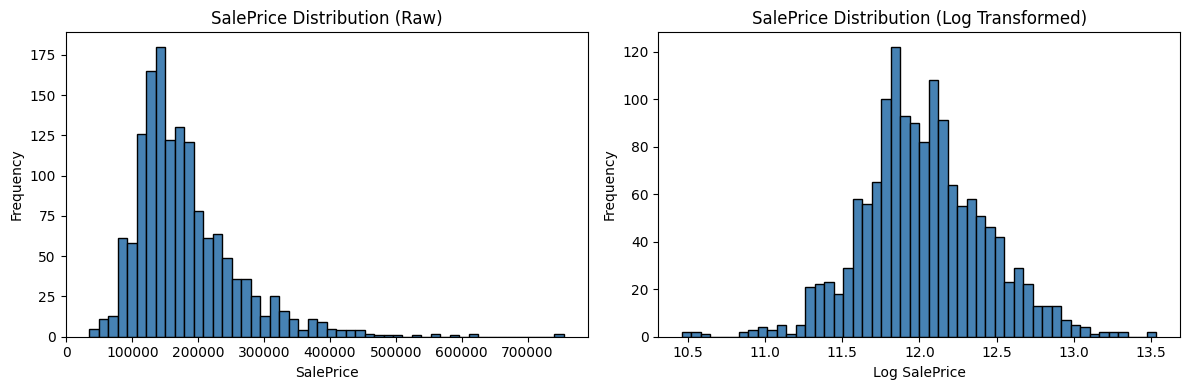

Skewness (raw):     1.88
Skewness (log):     0.12


In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Raw SalePrice distribution
axes[0].hist(train['SalePrice'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('SalePrice Distribution (Raw)')
axes[0].set_xlabel('SalePrice')
axes[0].set_ylabel('Frequency')

# Log transformed
axes[1].hist(np.log(train['SalePrice']), bins=50, color='steelblue', edgecolor='black')
axes[1].set_title('SalePrice Distribution (Log Transformed)')
axes[1].set_xlabel('Log SalePrice')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

print(f"Skewness (raw):     {train['SalePrice'].skew():.2f}")
print(f"Skewness (log):     {np.log(train['SalePrice']).skew():.2f}")

A skewness of above 0.5 means that the dataset needs to be log transformed in order to make it normally distributed. As we can see the log transformed data has a skewness of 0.12, which is essentially normal. 

In [8]:
#Lets see what numerical columns are the most correlated to the label, which is the Sale Price. 
numeric_cols = train.select_dtypes(include=['int64', 'float64']).columns
corr = train[numeric_cols].corr()['SalePrice'].sort_values(ascending=False)
print(corr)

SalePrice        1.000000
OverallQual      0.790982
GrLivArea        0.708624
GarageCars       0.640409
GarageArea       0.623431
TotalBsmtSF      0.613581
1stFlrSF         0.605852
FullBath         0.560664
TotRmsAbvGrd     0.533723
YearBuilt        0.522897
YearRemodAdd     0.507101
MasVnrArea       0.472614
Fireplaces       0.466929
BsmtFinSF1       0.386420
LotFrontage      0.349876
WoodDeckSF       0.324413
2ndFlrSF         0.319334
OpenPorchSF      0.315856
HalfBath         0.284108
LotArea          0.263843
GarageYrBlt      0.261366
BsmtFullBath     0.227122
BsmtUnfSF        0.214479
BedroomAbvGr     0.168213
ScreenPorch      0.111447
PoolArea         0.092404
MoSold           0.046432
3SsnPorch        0.044584
BsmtFinSF2      -0.011378
BsmtHalfBath    -0.016844
MiscVal         -0.021190
Id              -0.021917
LowQualFinSF    -0.025606
YrSold          -0.028923
OverallCond     -0.077856
MSSubClass      -0.084284
EnclosedPorch   -0.128578
KitchenAbvGr    -0.135907
Name: SalePr

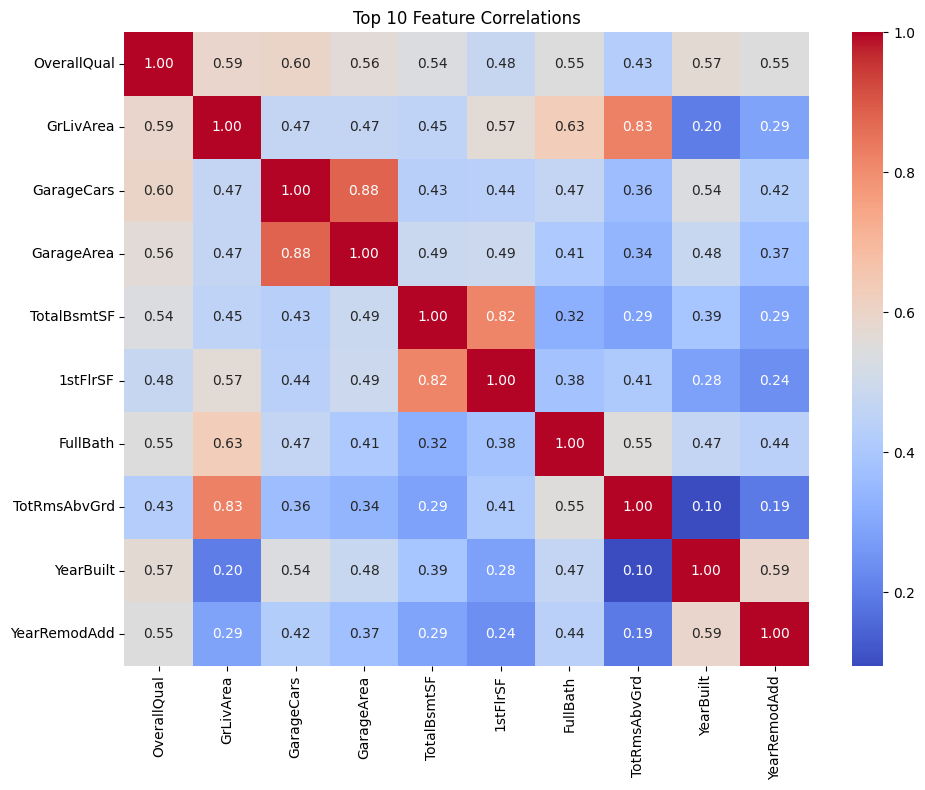

In [9]:
#Now we can add a heatmap feature for the top 10 correlated columns excluding the Sale Price column. 
top_features = corr[1:11].index  # top 10 excluding SalePrice itself

plt.figure(figsize=(10, 8))
sns.heatmap(train[top_features].corr(), annot=True, fmt='.2f', cmap='coolwarm')
plt.title('Top 10 Feature Correlations')
plt.tight_layout()
plt.show()


In [10]:
# Combine bathroom counts into one feature
train['TotalBath'] = train['FullBath'] + 0.5*train['HalfBath'] + train['BsmtFullBath'] + 0.5*train['BsmtHalfBath']

# Total square footage across the house
train['TotalSF'] = train['TotalBsmtSF'] + train['1stFlrSF'] + train['2ndFlrSF']

# House age at time of sale
train['HouseAge'] = train['YrSold'] - train['YearBuilt']
train['YearsSinceRemodel'] = train['YrSold'] - train['YearRemodAdd']

In [11]:
train['ExterQual'].unique()
# ['Gd', 'TA', 'Ex', 'Fa'] — Excellent > Good > Typical > Fair > Poor

array(['Gd', 'TA', 'Ex', 'Fa'], dtype=object)

Features like ExterQual, KitchenQual, BsmtQual, GarageQual, PoolQC, FireplaceQu all follow this Ex/Gd/TA/Fa/Po pattern. If we one-hot encode these, we throw away the ranking information, the model has to relearn from scratch that "Excellent" is better than "Fair." If we instead map them to numbers, the model can use that order directly.

In [12]:
qual_map = {'Ex': 5, 'Gd': 4, 'TA': 3, 'Fa': 2, 'Po': 1, 'None': 0}

ordinal_cols = ['ExterQual', 'ExterCond', 'BsmtQual', 'BsmtCond', 
                 'HeatingQC', 'KitchenQual', 'FireplaceQu', 
                 'GarageQual', 'GarageCond', 'PoolQC']

for col in ordinal_cols:
    train[col] = train[col].map(qual_map)

In [13]:
nominal_cols = ['MSZoning', 'Street', 'Alley', 'LandContour', 'LotConfig',
                 'Neighborhood', 'Condition1', 'Condition2', 'BldgType',
                 'HouseStyle', 'RoofStyle', 'RoofMatl', 'Exterior1st',
                 'Exterior2nd', 'MasVnrType', 'Foundation', 'Heating',
                 'Electrical', 'GarageType', 'MiscFeature', 'SaleType',
                 'SaleCondition']

train = pd.get_dummies(train, columns=nominal_cols, drop_first=True)

In [14]:
print(train.shape)
print(train.dtypes.value_counts())

# Should be empty — no object columns left
print(train.select_dtypes(include='object').columns.tolist())

(1460, 208)
bool       145
int64       48
object      11
float64      4
Name: count, dtype: int64
['LotShape', 'Utilities', 'LandSlope', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'CentralAir', 'Functional', 'GarageFinish', 'PavedDrive', 'Fence']


In [15]:
remaining_maps = {
    'LotShape': {'Reg': 4, 'IR1': 3, 'IR2': 2, 'IR3': 1},
    'Utilities': {'AllPub': 4, 'NoSewr': 3, 'NoSeWa': 2, 'ELO': 1},
    'LandSlope': {'Gtl': 3, 'Mod': 2, 'Sev': 1},
    'BsmtExposure': {'Gd': 4, 'Av': 3, 'Mn': 2, 'No': 1, 'None': 0},
    'BsmtFinType1': {'GLQ': 6, 'ALQ': 5, 'BLQ': 4, 'Rec': 3, 'LwQ': 2, 'Unf': 1, 'None': 0},
    'BsmtFinType2': {'GLQ': 6, 'ALQ': 5, 'BLQ': 4, 'Rec': 3, 'LwQ': 2, 'Unf': 1, 'None': 0},
    'CentralAir': {'Y': 1, 'N': 0},
    'Functional': {'Typ': 8, 'Min1': 7, 'Min2': 6, 'Mod': 5, 'Maj1': 4, 'Maj2': 3, 'Sev': 2, 'Sal': 1},
    'GarageFinish': {'Fin': 3, 'RFn': 2, 'Unf': 1, 'None': 0},
    'PavedDrive': {'Y': 2, 'P': 1, 'N': 0},
    'Fence': {'GdPrv': 4, 'MnPrv': 3, 'GdWo': 2, 'MnWw': 1, 'None': 0},
}

for col, mapping in remaining_maps.items():
    train[col] = train[col].map(mapping)

# Verify — should print an empty list and 0
print(train.select_dtypes(include='object').columns.tolist())
print(train.isnull().sum().sum())

[]
0


In [16]:
#Removing outliers
train = train[~((train['GrLivArea'] > 4000) & (train['SalePrice'] < 300000))]

In [17]:
train.drop(columns=['Id'], inplace=True)

# Split features and log-transformed target
X = train.drop(columns=['SalePrice'])
y = np.log(train['SalePrice'])

#Log transform predictors like LotArea and GrLivArea since they are heavily skewed
from scipy.stats import skew
numeric_feats = X.dtypes[X.dtypes != 'bool'].index
skewed = X[numeric_feats].apply(lambda x: skew(x)).sort_values(ascending=False)
high_skew = skewed[skewed > 0.75].index
X[high_skew] = np.log1p(X[high_skew])

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
print(X_train.shape, X_test.shape)

(1166, 206) (292, 206)


Then baseline Random Forest to get our reference point before XGBoost:

In [18]:
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

rf_pred_log = rf.predict(X_test)
rf_pred = np.exp(rf_pred_log)
y_test_actual = np.exp(y_test)

print(f"MAE:  {mean_absolute_error(y_test_actual, rf_pred):.2f}")
print(f"R²:   {r2_score(y_test_actual, rf_pred):.2f}")

MAE:  16025.67
R²:   0.90


In [19]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=1000,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

xgb.fit(X_train, y_train)

xgb_pred = np.exp(xgb.predict(X_test))

print(f"MAE:  {mean_absolute_error(y_test_actual, xgb_pred):.2f}")
print(f"R²:   {r2_score(y_test_actual, xgb_pred):.2f}")

MAE:  14456.89
R²:   0.93


In [20]:
from sklearn.model_selection import RandomizedSearchCV

param_dist = {
    'n_estimators': [500, 1000, 1500],
    'learning_rate': [0.01, 0.03, 0.05, 0.1],
    'max_depth': [3, 4, 5, 6],
    'subsample': [0.7, 0.8, 0.9, 1.0],
    'colsample_bytree': [0.7, 0.8, 0.9, 1.0],
    'min_child_weight': [1, 3, 5]
}

random_search = RandomizedSearchCV(
    XGBRegressor(random_state=42),
    param_distributions=param_dist,
    n_iter=50,          # try 50 random combinations
    cv=5,
    scoring='r2',
    n_jobs=-1,
    verbose=1,
    random_state=42
)

random_search.fit(X, y)

print("Best params:", random_search.best_params_)
print("Best CV R²: ", round(random_search.best_score_, 4))

Fitting 5 folds for each of 50 candidates, totalling 250 fits
Best params: {'subsample': 0.7, 'n_estimators': 1000, 'min_child_weight': 5, 'max_depth': 4, 'learning_rate': 0.03, 'colsample_bytree': 0.7}
Best CV R²:  0.9154


MAE:  4961.20
R²:   0.99


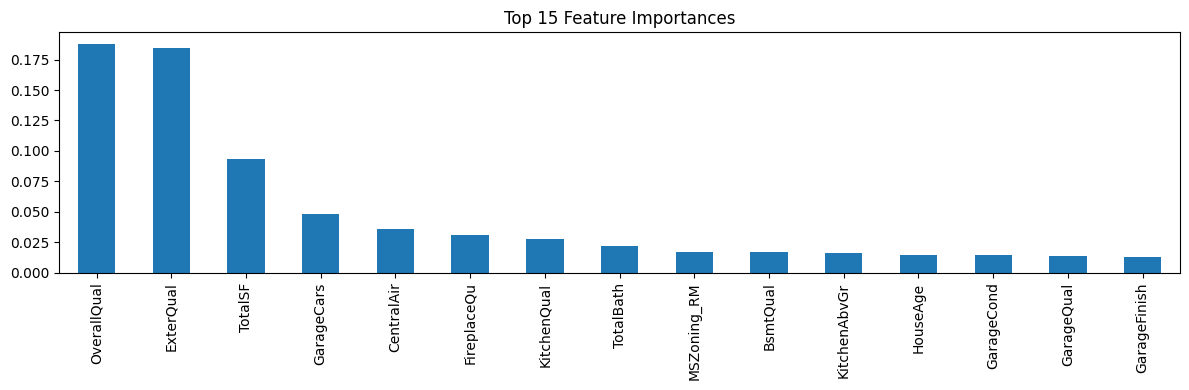

In [21]:
best_xgb = random_search.best_estimator_

xgb_pred = np.exp(best_xgb.predict(X_test))

print(f"MAE:  {mean_absolute_error(y_test_actual, xgb_pred):.2f}")
print(f"R²:   {r2_score(y_test_actual, xgb_pred):.2f}")

# Top 15 feature importances
importances = pd.Series(best_xgb.feature_importances_, index=X.columns)
importances.sort_values(ascending=False).head(15).plot(kind='bar', figsize=(12, 4), title='Top 15 Feature Importances')
plt.tight_layout()
plt.show()

Why 0.99 is not real:
When we ran random_search.fit(X, y), it did cross validation on all the data, and then it refit the best model on the entire dataset, including our 292 test rows. So best_xgb has seen X_test during training. 

The trustworthy number is the CV score: 0.9154.

Lets retrain with the best params on X_train only:

In [22]:
xgb_final = XGBRegressor(
    **random_search.best_params_,
    random_state=42
)
xgb_final.fit(X_train, y_train)

xgb_pred = np.exp(xgb_final.predict(X_test))

print(f"MAE:  {mean_absolute_error(y_test_actual, xgb_pred):.2f}")
print(f"R²:   {r2_score(y_test_actual, xgb_pred):.2f}")

MAE:  13669.94
R²:   0.94


During my first iteration I got a score of 0.91, then I removed outliers in the GrLivArea and SalePrice columns which increased my score to 0.94. Then I tried to logtransform predictors like LotArea and GrLivArea which were heavily skewed, but this didn't increase my score. I ended up with 0.94 once again. This is likely due to the fact that XGBoost only cares about split order. Since log is order preserving, there was no change.